# Land Cover Classification with CNNs

Classificação de imagens de satélite em:
- Agriculture
- Forest
- Residential
- Water

Comparação entre duas CNNs desenvolvidas do zero:
- SimpleCNN
- DeepCNN


In [1]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)


In [2]:
DATASET_PATH = "../dataset"
IMAGE_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", DEVICE)


Dispositivo: cpu


## Carregamento e Preparação do Dataset

Classes: ['Agriculture', 'Forest', 'Residential', 'Water']
{'Agriculture': 1500, 'Forest': 1000, 'Residential': 1000, 'Water': 1000}


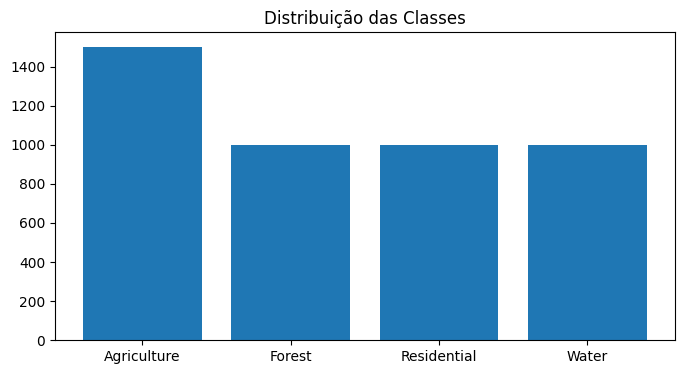

In [10]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

class_count = {name: 0 for name in class_names}

for _, label in dataset:
    class_count[class_names[label]] += 1

print(class_count)

plt.figure(figsize=(8,4))
plt.bar(class_count.keys(), class_count.values())
plt.title("Distribuição das Classes")
plt.show()


In [11]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Treino:", len(train_ds))
print("Validação:", len(val_ds))
print("Teste:", len(test_ds))


Treino: 3150
Validação: 675
Teste: 675


## Visualização de Amostras

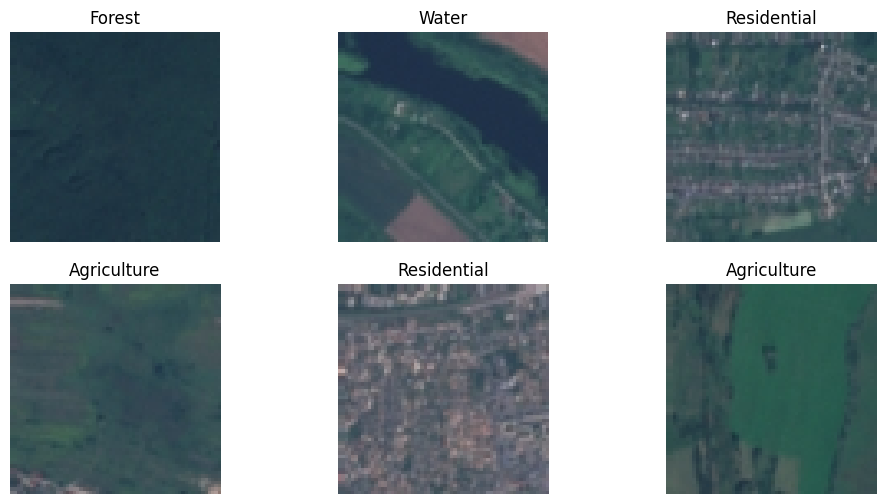

In [21]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,6))

for i in range(min(6, len(images))):
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()


## SimpleCNN

In [13]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## DeepCNN

In [14]:
class DeepCNN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Treinamento

In [16]:
def train_model(model, name="Model"):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_weights = copy.deepcopy(model.state_dict())
    best_acc = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(EPOCHS):

        model.train()

        total, correct, loss_sum = 0, 0, 0

        for x, y in train_loader:

            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            out = model(x)

            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

            pred = out.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

        train_losses.append(loss_sum / len(train_loader))
        train_accs.append(100 * correct / total)

        model.eval()
        total, correct, loss_sum = 0, 0, 0

        with torch.no_grad():

            for x, y in val_loader:

                x, y = x.to(DEVICE), y.to(DEVICE)

                out = model(x)
                loss = criterion(out, y)

                loss_sum += loss.item()

                pred = out.argmax(1)

                correct += (pred == y).sum().item()
                total += y.size(0)

        val_losses.append(loss_sum / len(val_loader))
        val_accs.append(100 * correct / total)

        if val_accs[-1] > best_acc:
            best_acc = val_accs[-1]
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, train_accs, val_accs


In [17]:
simple_model = SimpleCNN(num_classes)
simple_model, s_tl, s_vl, s_ta, s_va = train_model(simple_model, "SimpleCNN")

deep_model = DeepCNN(num_classes)
deep_model, d_tl, d_vl, d_ta, d_va = train_model(deep_model, "DeepCNN")


## Comparação de Métricas

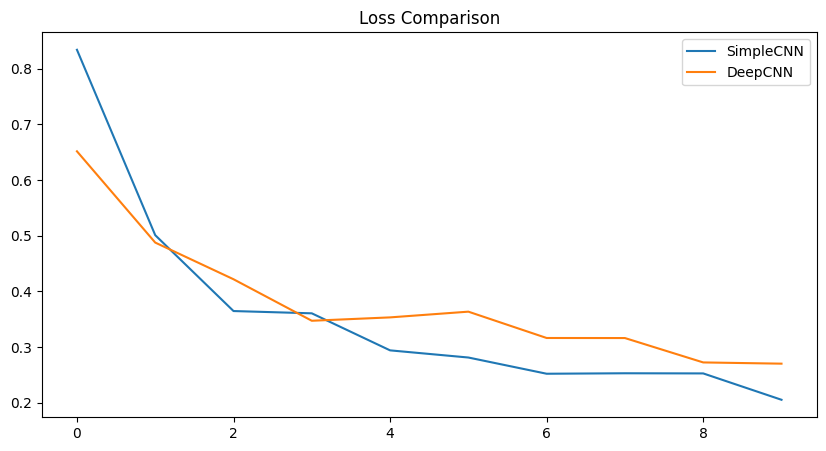

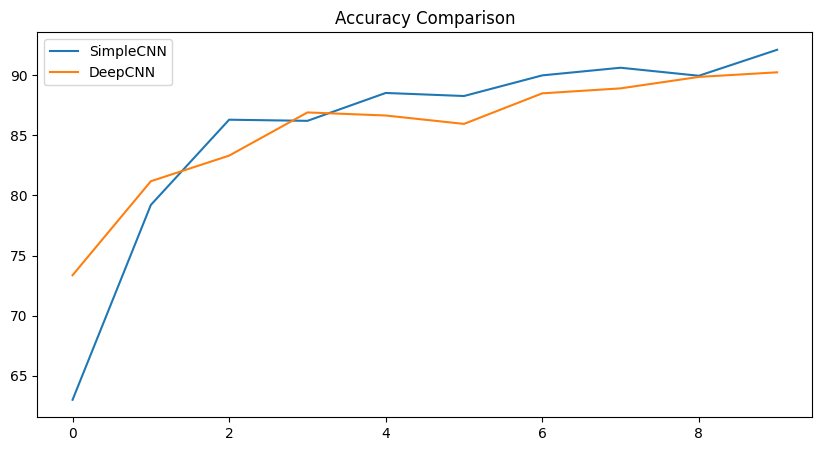

In [18]:
plt.figure(figsize=(10,5))
plt.plot(s_tl,label="SimpleCNN")
plt.plot(d_tl,label="DeepCNN")
plt.title("Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(s_ta,label="SimpleCNN")
plt.plot(d_ta,label="DeepCNN")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()


## Avaliação e Matriz de Confusão

Accuracy: 0.9318518518518518
              precision    recall  f1-score   support

 Agriculture       0.92      0.92      0.92       215
      Forest       0.98      0.91      0.94       150
 Residential       1.00      0.99      0.99       153
       Water       0.85      0.92      0.89       157

    accuracy                           0.93       675
   macro avg       0.94      0.93      0.93       675
weighted avg       0.93      0.93      0.93       675



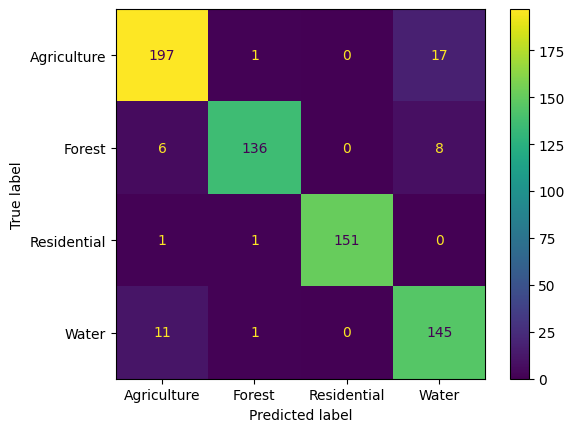

In [19]:
def evaluate_model(model):

    predictions = []
    targets = []

    model.eval()

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, predictions)

    print("Accuracy:", acc)

    print(classification_report(
        targets,
        predictions,
        target_names=class_names
    ))

    cm = confusion_matrix(targets, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot()
    plt.show()

evaluate_model(deep_model)


## Predição de Nova Imagem

In [ ]:
def predict_image(path, model):

    image = Image.open(path).convert("RGB")

    img = transform(image).unsqueeze(0).to(DEVICE)

    model.eval()

    with torch.no_grad():
        output = model(img)

        probabilities = torch.softmax(output, dim=1)

        confidence, prediction = torch.max(probabilities, 1)

    plt.imshow(image)
    plt.title(
        f'Predição: {class_names[prediction.item()]} | {confidence.item()*100:.2f}%'
    )
    plt.axis('off')
    plt.show()
